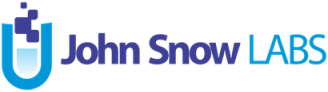

# 🚀 JohnSnowLabs Medical LLM Inference Server

### 🔄 Pulling Required Images

The necessary Docker images to run the LLM have already been pulled from
👉 [Docker Hub](https://hub.docker.com/r/johnsnowlabs/jsl-llms)

---

### 🐳 Containers Running on System Startup

The containers are configured to start automatically when the system boots.

You can verify the running containers with:

```bash
docker ps
```

You should see **two containers** running:

* **`johnsnowlabs/jsl-llms:0.19.0`** – runs the LLM service.
* **`ghcr.io/open-webui/open-webui:main`** – provides the WebUI interface to interact with the model.

---

### 📜 Viewing Container Logs

You can monitor the logs for any container using:

```bash
docker logs <container-id>
```

The logs display important information such as:

* Model initialization and loading progress
* License validation status
* Server startup confirmation
* Memory usage and GPU configuration
* Model task capabilities
* Available API endpoints and routes
* Health check status

---

#### ✅ Example: Successful Startup Log (for `johnsnowlabs/jsl-llms:0.19.0`)

```bash
INFO: Application startup complete.
llm-service [INFO] Server is healthy and model is loaded
INFO: Started server process [1]
INFO:     127.0.0.1:42154 - "GET /health HTTP/1.1" 200 OK
```

Once you see these messages, the service is **ready to accept requests!** 🎉



## Imports

In [10]:
import json
import re
import requests

## Initial setup

In [11]:
prompt1 = """A 95-year-old woman who is a resident at a long term care facility, got up from her chair, tripped on a rug, and fell on her right knee. She could not get up without assistance and complained of severe pain in her right hip and buttock. The nurse who evaluated her tried to stand her up, but when the patient tried to stand on her right leg, she dropped her left hip and lost her balance. The nurse then recognized that her patient had a foreshortened right leg fixed in the adducted position and a large swelling in her right buttock. At the receiving hospital, the patient was confused and, though she knew her name, she couldn't remember the date and insists to leave the hospital immediately to see her family. Past medical history includes diabetes, congestive heart failure, and incontinence. She is currently taking metformin, lisinopril, hydrochlorothiazide, metoprolol, and oxybutynin. Physical exam confirmed the nurse's findings. Radiographs proved the presence of a right posterior hip dislocation without fractures. What medication is most likely associated with this patient's confusion?
A. Metformin
B. Oxybutynin
C. Metoprolol
D. Lisinopril"""

prompt2 = """A 47-year-old man comes to the physician because of severe retrosternal chest pain and shortness of breath for 45 minutes. He has dyslipidemia, hypertension, and type 2 diabetes mellitus. Current medications include hydrochlorothiazide, lisinopril, metformin, and atorvastatin. He has smoked 1 pack of cigarettes daily for 20 years. He appears pale and diaphoretic. His temperature is 37°C (98.6°F), pulse is 115/min, and blood pressure is 140/70 mm Hg. Breath sounds are normal. The remainder of the examination shows no abnormalities. An ECG shows left ventricular hypertrophy with ST-segment elevation in leads I, aVL, and V1–V6. High-dose aspirin, clopidogrel, metoprolol, sublingual nitroglycerin, and unfractionated heparin are administered. As the patient awaits transport to the nearest emergency room, he collapses and becomes unresponsive. His pulse and blood pressure cannot be detected. Despite resuscitative efforts, the patient dies. Which of the following is the most likely cause of death in this patient?
A. Papillary muscle rupture
B. Ventricular fibrillation
C. Septal wall rupture
D. Pulmonary embolism"""



In [18]:
def print_colored(text, color='green'):
    colors = {
        'green': '\033[92m',
        'reset': '\033[0m',
    }
    color_code = colors.get(color, colors['reset'])
    print(f"{color_code}{text}{colors['reset']}", end="", flush=True)

# Health & Version:

In [19]:
url = "http://localhost:80/health"
response = requests.get(url)
print("Health:", response.status_code, response.text)

Health: 200 {"status":"ok","model":"Medical-LLM-Medium","pipeline_enabled":true}


# Core Functionality:

### List available models

In [20]:
url = "http://localhost:80/v1/models"
response = requests.get(url)
print("Models:", response.json())

Models: {'object': 'list', 'data': [{'id': 'Medical-LLM-Medium', 'object': 'model', 'owned_by': 'JSL', 'permission': [], 'root': 'Medical-LLM-Medium', 'parent': None}]}


## Non-Streaming Responses

In [21]:
def get_completion_response(url, payload):
    """
    Handles non-streaming responses from /v1/chat/completions.
    """
    response = requests.post(url, json=payload)
    response.raise_for_status()
    return response.json()


#### Example 1


In [22]:
url = "http://localhost:80/v1/chat/completions"
payload = {
    "model": "Medical-LLM-Medium",
    "messages": [
        {"role": "user", "content": prompt1},
    ],
    "stream": False,
}

response = get_completion_response(url, payload)
message = response["choices"][0]["message"]

reasoning_content = message.get("reasoning")
content = message.get("content")

print_colored(reasoning_content, 'green')
print_colored(content, 'reset')


Here's a thinking process:

1.  **Analyze User Input:**
   - **Patient:** 95-year-old woman, LTCF resident
   - **Event:** Tripped, fell on right knee, severe pain in right hip/buttock
   - **Exam/Nurse findings:** Foreshortened right leg fixed in adducted position, large swelling in right buttock -> indicates posterior hip dislocation
   - **Hospital findings:** Confused, knows name but not date, wants to leave immediately (delirium)
   - **PMH:** Diabetes, CHF, incontinence
   - **Medications:** Metformin, lisinopril, hydrochlorothiazide, metoprolol, oxybutynin
   - **Question:** What medication is most likely associated with this patient's confusion?
   - **Options:** A. Metformin, B. Oxybutynin, C. Metoprolol, D. Lisinopril

2.  **Identify Key Clinical Concepts:**
   - Elderly patient presenting with acute confusion/delirium.
   - Medication review for anticholinergic burden/side effects.
   - Oxybutynin is a strong antimuscarinic/anticholinergic agent used for urinary incontinence

#### Example 2


In [23]:
url = "http://localhost:80/v1/chat/completions"
payload = {
    "model": "Medical-LLM-Medium",
    "messages": [
        {"role": "user", "content": prompt2},
    ],
    "stream": False,
}

response = get_completion_response(url, payload)
message = response["choices"][0]["message"]

reasoning_content = message.get("reasoning")
content = message.get("content")

print_colored(reasoning_content, 'green')
print_colored(content, 'reset')


Here's a thinking process:

1.  **Analyze User Input:**
   - **Patient:** 47-year-old man
   - **Symptoms:** Severe retrosternal chest pain, shortness of breath for 45 min
   - **PMH:** Dyslipidemia, hypertension, T2DM
   - **Medications:** HCTZ, lisinopril, metformin, atorvastatin
   - **Social Hx:** Smoker (1 pack/day x 20 yrs)
   - **Vitals:** T 37°C, HR 115, BP 140/70
   - **Exam:** Pale, diaphoretic. Otherwise normal.
   - **ECG:** LVH, ST-elevation in I, aVL, V1-V6 (suggests extensive anterior/lateral STEMI)
   - **Treatment given:** Aspirin, clopidogrel, metoprolol, NTG, heparin
   - **Event:** Collapses, unresponsive, pulseless, BP unmeasurable while awaiting transport. Dies despite resuscitation.
   - **Question:** Most likely cause of death?
   - **Options:** A. Papillary muscle rupture, B. Ventricular fibrillation, C. Septal wall rupture, D. Pulmonary embolism

2.  **Identify Key Clinical Features & Timing:**
   - Acute STEMI presentation (chest pain, diaphoresis, ST elevati

# Streaming Responses

In [24]:
def stream_response(url, payload):
    """
    Handles streaming responses from both `/v1/chat/completions` and `/v1/completions`.

    Args:
        url (str): The API endpoint URL.
        payload (dict): The JSON payload for the request.

    Yields:
        dict: A chunk with 'type' and 'content' keys.
              Types: 'reasoning', 'content', 'text', 'error'
    """
    is_chat_completion = "messages" in payload

    try:
        response = requests.post(url, json=payload, stream=True)

        for chunk in response.iter_lines():
            if chunk:
                decoded = chunk.decode("utf-8")
                if decoded.startswith("data: "):
                    data = decoded[len("data: "):]
                    if data.strip() == "[DONE]":
                        break
                    try:
                        parsed = json.loads(data)
                        choices = parsed.get("choices", [])
                        if not choices:
                            continue
                        choice = choices[0]

                        if is_chat_completion:
                            delta = choice.get("delta", {})
                            if "reasoning" in delta:
                                yield {'type': 'reasoning', 'content': delta["reasoning"]}
                            elif "content" in delta and delta["content"]:
                                yield {'type': 'content', 'content': delta["content"]}
                        else:
                            text = choice.get("text")
                            if text:
                                yield {'type': 'text', 'content': text}

                    except json.JSONDecodeError:
                        continue

    except Exception as e:
        yield {'type': 'error', 'content': f"\nAn error occurred during streaming: {str(e)}"}

In [25]:
def handle_streaming_chunk(chunk):
    """
    Handles and prints a streaming chunk with appropriate formatting
    Args:
        chunk: Dictionary with 'type' and 'content' keys
    """
    if chunk['type'] == 'reasoning':
        print_colored(chunk['content'], 'green')
    elif chunk['type'] == 'content':
        print_colored(chunk['content'], 'reset')
    elif chunk['type'] == 'text':  # For text completion
        print(chunk['content'], end="", flush=True)
    elif chunk['type'] == 'error':
        print_colored(chunk['content'], 'reset')

### Chat Completion

In [26]:
url = "http://localhost:80/v1/chat/completions"
payload = {
    "model": "Medical-LLM-Medium",
    "messages": [
        {"role": "user", "content": prompt1},
    ],
    "stream": True,
}

for chunk in stream_response(url, payload):
    handle_streaming_chunk(chunk)


Here's a thinking process:

1.  **Analyze User Input:**
   - **Patient:** 95-year-old woman, long-term care resident.
   - **Event:** Fell on right knee, severe right hip/buttock pain, unable to bear weight.
   - **Exam/Nurse Findings:** Dropping left hip when standing on right, foreshortened right leg fixed in adduction, large swelling in right buttock.
   - **Radiograph:** Right posterior hip dislocation without fractures.
   - **Symptom:** Confused (knows name, doesn't know date, insists on leaving).
   - **PMH:** Diabetes, CHF, incontinence.
   - **Meds:** Metformin, lisinopril, hydrochlorothiazide, metoprolol, oxybutynin.
   - **Question:** What medication is most likely associated with this patient's confusion?
   - **Options:** A. Metformin, B. Oxybutynin, C. Metoprolol, D. Lisinopril

2.  **Identify Key Clinical Concepts:**
   - The patient is elderly (95yo) and presenting with acute confusion/delirium.
   - Medication side effects in the elderly are a common cause of delirium.